In [1]:
import pandas as pd
import numpy as np


from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#./clean_ds.xlsx
df = pd.read_excel("../processed/clean_ds.xlsx")

all_cols: list[str] = df.columns.tolist()
target: str = "referred_CXL"

## Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           824 non-null    int64  
 1   Atopy            824 non-null    int64  
 2   EXAM             824 non-null    int64  
 3   atopy_dummy      824 non-null    int64  
 4   kMax             824 non-null    float64
 5   PachyMin         824 non-null    float64
 6   ak1              824 non-null    float64
 7   ak2              824 non-null    float64
 8   KmF              824 non-null    float64
 9   Axis_F_(flat)    824 non-null    float64
 10  Astig_F_(D)      824 non-null    float64
 11  R_Per_F_(mm)     824 non-null    float64
 12  Rmin             824 non-null    float64
 13  Num_Ecc_F        824 non-null    float64
 14  Asph_Q_F         824 non-null    float64
 15  Rf_B_(mm)        824 non-null    float64
 16  Rs_B_(mm)        824 non-null    float64
 17  Rh_B_(mm)       

In [4]:
df.describe()

,Gender,Atopy,EXAM,atopy_dummy,kMax,PachyMin,ak1,ak2,KmF,Axis_F_(flat),...,D8mm_Pachy,D10mm_Pachy,D2mm_Prog,D4mm_Prog,D6mm_Prog,D8mm_Prog,D10mm_Prog,Last_Visit_Day,referred_CXL,age
count,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,...,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000,824.000000
mean,0.684466,0.037621,3.337379,0.129854,53.745007,463.601730,45.028841,48.110030,46.502713,84.782976,...,649.393553,444.307747,4.567319,15.656860,28.742601,42.686659,38.050929,-992.336165,0.243932,35.544903
std,0.465010,0.190394,1.524290,0.336347,5.695608,40.170616,3.361501,3.912727,3.522754,55.868174,...,77.598304,310.621604,1.578953,4.901832,7.834410,10.222524,28.189152,873.639980,0.429713,13.405370
min,0.000000,0.000000,2.000000,0.000000,41.900000,341.142857,36.833333,39.925000,39.450000,0.700000,...,0.000000,0.000000,1.000000,3.500000,0.000000,0.000000,0.000000,-3882.000000,0.000000,11.000000
25%,0.000000,0.000000,2.000000,0.000000,49.500000,440.000000,42.748214,45.215000,43.979167,31.583333,...,630.937500,124.625000,3.500000,12.333333,23.500000,36.666667,10.107143,-1366.750000,0.000000,24.000000
50%,1.000000,0.000000,3.000000,0.000000,52.700000,465.000000,44.350000,47.350000,45.870833,80.200000,...,659.000000,506.333333,4.333333,15.000000,27.666667,41.633333,41.000000,-722.000000,0.000000,34.000000
75%,1.000000,0.000000,4.000000,0.000000,57.227500,488.666667,46.675000,50.400000,48.406250,138.875000,...,685.500000,740.312500,5.333333,18.333333,33.000000,48.000000,61.333333,-326.750000,0.000000,45.000000
max,1.000000,1.000000,12.000000,1.000000,77.233333,577.666667,59.600000,64.700000,60.950000,178.033333,...,802.000000,917.500000,15.500000,49.000000,79.000000,95.000000,120.000000,-30.000000,1.000000,78.000000


## Gender distribution

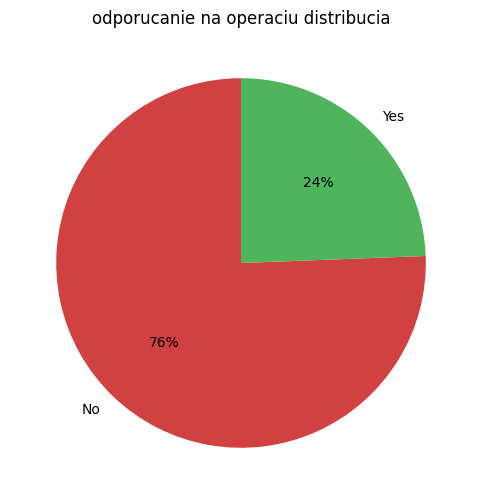

In [5]:
plt.figure(figsize=(6,6))
counts = df[target].value_counts()
labels = ["No" if x == 0 else "Yes" for x in counts.index]
colors = ["#d24141" if x == 0 else "#4fb55d" for x in counts.index]

plt.pie(x=counts.values,          # type: ignore
        labels=labels,
        autopct="%.0f%%",
        startangle=90,
        colors=colors
        )

plt.title("odporucanie na operaciu distribucia")
plt.show()

## Odporucenie na CLX

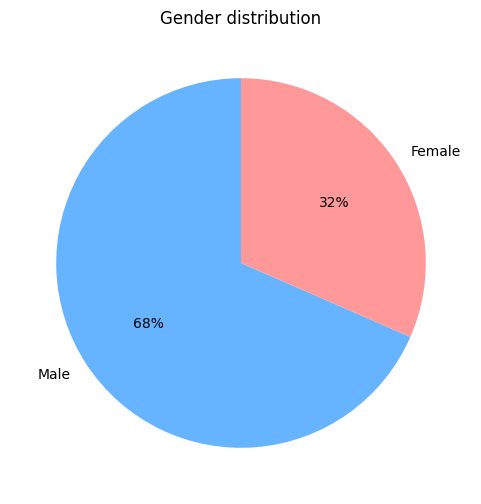

In [6]:
plt.figure(figsize=(6,6))
counts = df["Gender"].value_counts()
labels = ["Female" if x == 0 else "Male" for x in counts.index]
colors = ['#ff9999' if x == 0 else '#66b3ff' for x in counts.index]

plt.pie(x=counts.values,          # type: ignore
        labels=labels,
        autopct="%.0f%%",
        startangle=90,
        colors=colors
        )

plt.title("Gender distribution")
plt.show()

## Age distribution

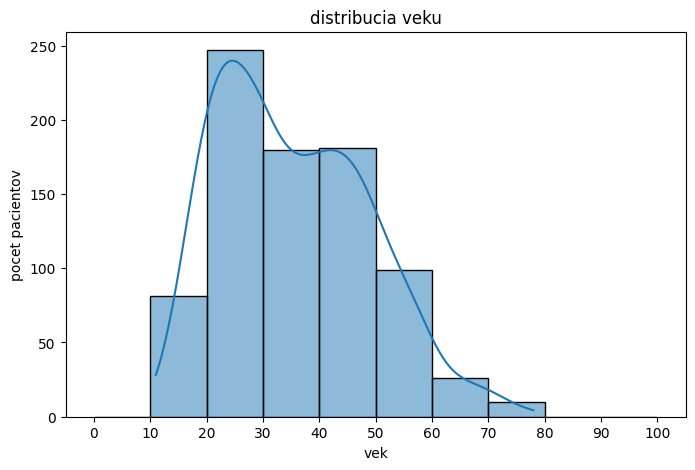

In [7]:
bins = list(range(0, 101, 10))

plt.figure(figsize=(8, 5))
sns.histplot(df["age"],         # type: ignore
             bins=bins,
             edgecolor="black",
             kde=True
             )
plt.xlabel("vek")
plt.ylabel("pocet pacientov")
plt.title("distribucia veku")
plt.xticks(bins)
plt.show()

## Korelacia medzi predikovanou premennou a atributami
- Heatmap-a nepripada do uvahy, mame vela atributov = bola by necitatelna

In [8]:
corr = (
    df
    .corr(method="spearman")[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)


In [9]:
corr

age               -0.460034
EXAM               0.403602
D8mm_Prog          0.225062
D10mm_Prog         0.209167
R_Per_F_(mm)       0.202094
IHD                0.201684
Pachy_Min_Pos_Y    0.186882
D2mm_Prog          0.184217
atopy_dummy        0.167290
D4mm_Prog          0.166563
Rmin_B            -0.166483
D6mm_Prog          0.164765
ISV                0.154223
Pachy_Apex        -0.149500
IVA                0.145948
KI                 0.140661
D10mm_Pachy        0.138746
kMax               0.131329
PachyMin          -0.131229
Rmin              -0.129114
D0mm_Pachy        -0.128817
CKI                0.128342
RSagMin           -0.122182
Astig_F_(D)        0.121637
Asph_Q_F          -0.119628
C_Vol_D_3mm       -0.114444
Rv_B_(mm)         -0.111412
Astig_B_(D)        0.108326
D2mm_Pachy        -0.108270
pk2               -0.102298
Rs_B_(mm)         -0.101510
IHA                0.091750
C_Vol_D_5mm       -0.082655
Num_Ecc_F          0.080524
Km_B_(mm)         -0.077475
Rm_B_(mm)         -0

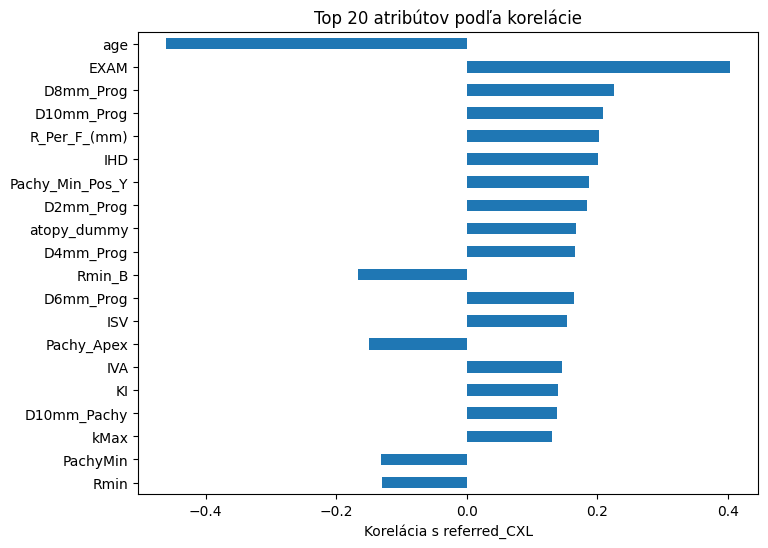

In [10]:
corr.head(20).plot(
    kind="barh",
    figsize=(8,6)
)

plt.xlabel("Korelácia s referred_CXL")
plt.title("Top 20 atribútov podľa korelácie")
plt.gca().invert_yaxis()
plt.show()


## data transformation (standardization)

- lebo log. regiresia, MLP, K-means (K-means nie na 100%)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           824 non-null    int64  
 1   Atopy            824 non-null    int64  
 2   EXAM             824 non-null    int64  
 3   atopy_dummy      824 non-null    int64  
 4   kMax             824 non-null    float64
 5   PachyMin         824 non-null    float64
 6   ak1              824 non-null    float64
 7   ak2              824 non-null    float64
 8   KmF              824 non-null    float64
 9   Axis_F_(flat)    824 non-null    float64
 10  Astig_F_(D)      824 non-null    float64
 11  R_Per_F_(mm)     824 non-null    float64
 12  Rmin             824 non-null    float64
 13  Num_Ecc_F        824 non-null    float64
 14  Asph_Q_F         824 non-null    float64
 15  Rf_B_(mm)        824 non-null    float64
 16  Rs_B_(mm)        824 non-null    float64
 17  Rh_B_(mm)       